# **클래스를 사용한 달착륙선 PPO 실습**

### 라이브러리 설치

In [1]:
!pip install gymnasium[box2d]
import gymnasium as gym
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_probability as tfp


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 98.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 102.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 96.5 MB/s eta 0:00:00




---



### 클래스 파일 업로드

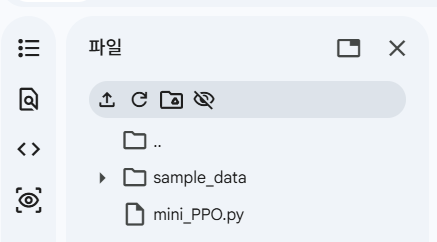

In [2]:
!wget https://raw.githubusercontent.com/hongjai-rhee/public/master/mini_PPO.py  # 클래스가 정의된 파일 지정
from mini_PPO import *   # 미리 만들어진 5개 PPO 클래스 임포트

--2026-08-02 05:15:20--  https://raw.githubusercontent.com/hongjai-rhee/public/master/mini_PPO.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12625 (12K) [text/plain]
Saving to: ‘mini_PPO.py’

mini_PPO.py         100%[===================>]  12.33K  --.-KB/s    in 0s      

2026-08-02 05:15:20 (134 MB/s) - ‘mini_PPO.py’ saved [12625/12625]





---


### **환경/모델 설정과 메인 학습 루프**

로우레벨 코드는 SB3보다 시간이 오래 걸려, 작동 원리만 확인하기 위해
* 총 학습 횟수인 TOTAL_STEPS를 10,000으로 지정하였습니다.   
* 완전한 학습을 위해서는 2백만번 이상의 학습이 필요할 수 있습니다.

In [3]:
# 환경 설정
env = gym.make('LunarLanderContinuous-v3')
state_dim  = env.observation_space.shape[0]   # 상태 수: 8
action_dim = env.action_space.shape[0]        # 행동 수: 2

# ── 모델 설정
setup    = ModelSetup(state_dim, action_dim,actor_lr=3e-4, critic_lr=3e-4) # 액터/크리틱 모델 설정

# ── 단계별 연산 방법 지정
take_act = TakeAction(setup)                                               # 행동 선택
rollout  = RolloutCollector(env, take_act, rollout_steps=1000)              # 경험 데이터 수집
eval_adv = EvaluateAdvantage(setup, gamma=0.99, lam=0.95)                  # 어드밴티지 계산(GAE 방법 적용)
update   = UpdateModel(setup, take_act, clip_eps=0.2, epochs=10, batch_size=256,
                       vf_coef=0.5,ent_coef = 0.05)                        # 모델 파라미터 업데이트

# ── 학습 루프 ──────────────────────────────────────────
TOTAL_STEPS = 10000   # 학습 횟수 지정(충분히 크게)

while rollout.step < TOTAL_STEPS:
    experience = rollout.collect()          # [1] 경험 데이터 수집
    exp_with_adv = eval_adv(experience)     # [2] 어드밴티지 계산
    losses = update(exp_with_adv)           # [3] 손실 계산 --> 업데이트

env.close()


  [Episode    1] Reward:  -469.06  Total_Steps:     125
  [Episode    2] Reward:  -562.98  Total_Steps:     226
  [Episode    3] Reward:   -63.15  Total_Steps:     313
  [Episode    4] Reward:  -452.42  Total_Steps:     416
  [Episode    5] Reward:  -381.60  Total_Steps:     514
  [Episode    6] Reward:  -684.75  Total_Steps:     636
  [Episode    7] Reward:  -517.86  Total_Steps:     727
  [Episode    8] Reward:   -70.77  Total_Steps:     816
  [Episode    9] Reward:  -350.71  Total_Steps:     918
  [Episode   10] Reward:  -369.88  Total_Steps:    1049
  [Episode   11] Reward:  -585.28  Total_Steps:    1207
  [Episode   12] Reward:  -520.19  Total_Steps:    1310
  [Episode   13] Reward:  -314.30  Total_Steps:    1413
  [Episode   14] Reward:  -446.35  Total_Steps:    1509
  [Episode   15] Reward:  -633.71  Total_Steps:    1676
  [Episode   16] Reward:  -442.52  Total_Steps:    1770
  [Episode   17] Reward:  -486.17  Total_Steps:    1915
  [Episode   18] Reward:  -451.78  Total_Steps: 

 EvaluateAdvantage 클래스에서는 **GAE**(Generalized Advantage Estimation) 기법을 사용했는데,
 * 이는 PPO 학습의 안전성을 더욱 강화하기 위해 책에서 설명한 어드밴티지 계산을 Exponential Moving Average 형태로 일부 변형한 것입니다.  
 * 간단한 문제에서는 원래의 어드밴티지 계산을 사용해도 좋습니다.

<iframe width="560" height="315" src="https://www.youtube.com/embed/QwJcF08hfs8?si=WO-buGL6CzIBOTCS" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>